In [5]:
import torch
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
import matplotlib.pyplot as plt

In [7]:
model = models.resnet18(weights=None)

In [8]:
import torch.nn as nn

model.fc = nn.Linear(
    in_features=512,
    out_features=4
)

In [9]:
model.load_state_dict(
    torch.load("../models/resnet18_brain_tumor.pth")
)

<All keys matched successfully>

In [10]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [11]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor()
])

In [12]:
classes = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

In [13]:
image = Image.open(r"C:\Users\nagas\OneDrive\Desktop\NeuroVision-AI\data\Testing\pituitary\Te-pi_14.jpg")

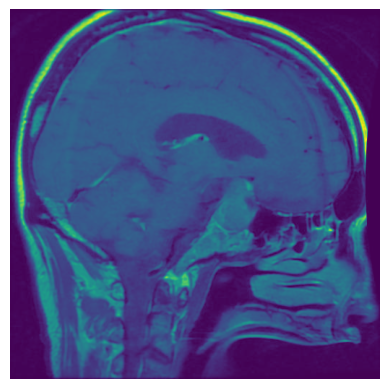

In [14]:
plt.imshow(image)
plt.axis("off")
plt.show()

In [15]:
image = transform(image)

In [16]:
print(image.shape)

torch.Size([3, 224, 224])


In [17]:
image = image.unsqueeze(0)

In [18]:
print(image.shape)

torch.Size([1, 3, 224, 224])


In [19]:
with torch.no_grad():

    outputs = model(image)

    _, predicted = torch.max(outputs,1)

In [20]:
print(predicted)

tensor([3])


In [21]:
print(classes[predicted.item()])

pituitary


In [22]:
actual_class = "meningioma"
predicted_class = classes[predicted.item()]

print("Actual class:", actual_class)
print("Predicted class:", predicted_class)

if actual_class == predicted_class:
    print("Prediction is correct ✅")
else:
    print("Prediction is incorrect ❌")

Actual class: meningioma
Predicted class: pituitary
Prediction is incorrect ❌
